In [103]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import random

from time import time

from scipy.special import comb, loggamma, lambertw
from scipy.stats import multinomial, expon

from silence_tensorflow import silence_tensorflow
silence_tensorflow()
import tensorflow as tf
import tensorflow_probability as tfp

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

import os, shutil
from pathlib import Path
import json
import subprocess

import thetaflow as thf
print("Thetaflow version: {}".format(thf.__version__))

import mps
import pwexp

Thetaflow version: 0.0.35


I0000 00:00:1783368387.565553    8648 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4312 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5


# MPS formulation

We write the pmf for $M \sim MPS(\theta, q; a_m, \phi(\cdot))$ as 
\begin{equation}
f_M(m) = \frac{a_m(q) \left[\phi(\theta)\right]^m}{A(\phi(\theta))}
\end{equation}

In [104]:
tf.clip_by_value(2.0, 0.0, np.inf)

<tf.Tensor: shape=(), dtype=float32, numpy=2.0>

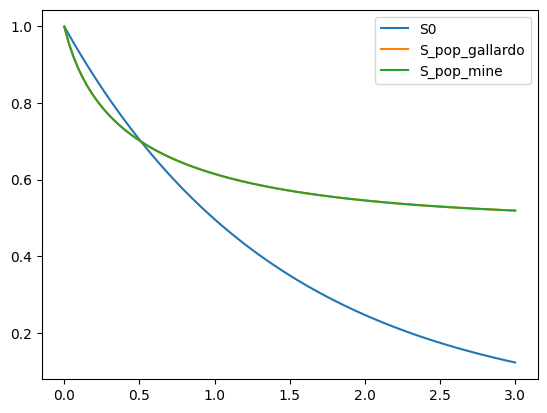

In [101]:
m = np.arange(0, 51).astype("float")

theta = 0.7

t = np.linspace(0, 3, 100)[:,None]
S_0 = lambda t, lam : np.exp( - lam * t )

S_pop_t = np.exp(-theta) * np.sum( (m+1)**(m-1) * ( theta*np.exp(-theta)*S_0(t, theta) )**m / np.exp(loggamma(m+1)), axis = 1 )

t_flat = t.flatten()

plt.plot( t_flat, S_0(t_flat, theta), label = "S0" )
plt.plot(t_flat, S_pop_t, label = "S_pop_gallardo")

phi = lambda theta : theta * np.exp(-theta)
phi_inv = lambda u : -lambertw(-u).real

num = np.exp( phi_inv( S_0(t, theta) * phi(theta) ) )
den = np.exp( theta )
plt.plot(t_flat, num / den, label = "S_pop_mine")

plt.legend()

plt.show()

In [67]:
(m+1)**(m-1)

array([1.00000000e+00, 1.00000000e+00, 3.00000000e+00, 1.60000000e+01,
       1.25000000e+02, 1.29600000e+03, 1.68070000e+04, 2.62144000e+05,
       4.78296900e+06, 1.00000000e+08, 2.35794769e+09, 6.19173642e+10,
       1.79216039e+12, 5.66939124e+13, 1.94619507e+15, 7.20575940e+16,
       2.86242305e+18, 1.21439531e+20, 5.48038686e+21, 2.62144000e+23,
       1.32484966e+25, 7.05429499e+26, 3.94715841e+28, 2.31551350e+30,
       1.42108547e+32, 9.10668577e+33, 6.08266788e+35, 4.22774530e+37,
       3.05313455e+39, 2.28767925e+41, 1.77618878e+43, 1.42724769e+45,
       1.18558347e+47, 1.01701029e+49, 9.00006122e+50, 8.20890115e+52,
       7.71010588e+54, 7.45091276e+56, 7.40270529e+58, 7.55578637e+60,
       7.91717805e+62, 8.51082412e+64, 9.38008295e+66, 1.05928400e+69,
       1.22500565e+71, 1.44992185e+73, 1.75551121e+75, 2.17318610e+77,
       2.74925967e+79, 3.55271368e+81, 4.68747138e+83])